# Retraining Cellpose on Custom Data

<div class="custom-button-row">
    <a 
        class="custom-button custom-download-button" href="../../../notebooks/05_segmentation/deep_learning/cellpose_retraining_colab.ipynb" download>
        <i class="fas fa-download"></i> Download this Notebook
    </a>
    <a
    class="custom-button custom-download-button" href="https://colab.research.google.com/github/bobiac/bobiac-book/blob/gh-pages/colab_notebooks/05_segmentation/deep_learning/cellpose_retraining_colab.ipynb" target="_blank">
        <img class="button-icon" src="../../../_static/logo/icon-google-colab.svg" alt="Open in Colab">
        Open in Colab
    </a>
</div>

In [ ]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "matplotlib",
#     "cellpose",
# ]
# ///

## Overview

In this section, we’ll walk through how to **retrain Cellpose on your own data**. This is useful when the default models don’t perform well on your specific cell type, staining method, or imaging modality.

Retraining allows Cellpose to learn directly from your examples—leading to better segmentation accuracy and more relevant masks for your experiments.

We’ll cover:
- Preparing your training data (images + label masks)
- Mounting your Google Drive to access files
- Setting training parameters
- Running the training process
- Evaluating the new model on test images


‼ MENTION NAPARI

> 💡 You’ll need pairs of raw microscopy images and their corresponding label masks. If you haven’t labeled your images yet, we recommend using the [Cellpose GUI](https://cellpose.readthedocs.io/en/latest/gui.html#training-your-own-cellpose-model) to draw or edit masks manually before starting.

The dataset we’ll use here can be downloaded below. It includes both training and test images:
<a href="../../../_static/data/05_segmentation_cellpose_training.zip" download>
<i class="fas fa-download"></i> Cellpose Training Dataset</a>

<p class="alert alert-warning">
    <strong>⚠️ Note:</strong> This notebook is designed to run in <a href="https://colab.research.google.com/github/bobiac/bobiac-book/blob/gh-pages/colab_notebooks/05_segmentation/deep_learning/cellpose_retraining_notebook.ipynb" target="_blank"> Google Colab</a>. If you want to run it locally, you may need to adjust some paths and install the required packages.
</p>

## Import Libraries

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from cellpose import core, io, metrics, models, train

## Setup

In [ ]:
io.logger_setup()  # to get printing of progress

use_gpu = core.use_gpu()
print("GPU available:", use_gpu)

## Data Handling

Cellpose expects images and their corresponding masks to live **in the same folder**, paired by a shared base name. Each image and mask share a numeric prefix — images have an `_img` suffix, masks have a `_labels` suffix.

Both the `train` and `test` folders follow the same layout:

```
cellpose_data/
├── train/
│   ├── 000_img.tif
│   ├── 000_labels.tif
│   ├── 001_img.tif
│   ├── 001_labels.tif
│   └── ...
└── test/
    ├── 008_img.tif
    ├── 008_labels.tif
    ├── 009_img.tif
    ├── 009_labels.tif
    └── ...
```

You'll also need to **split your data** into a `train` and a `test` folder. The model learns from the training set and is evaluated on the test set—images it has never seen during training.

> 💡 If you haven't labeled your images yet, the [Cellpose GUI](https://cellpose.readthedocs.io/en/latest/gui.html#training-your-own-cellpose-model) lets you draw or correct masks manually and saves them with the `_labels` suffix automatically.

The first step is to define the `train` and `test` directories, then load the data with [`io.load_train_test_data`](https://cellpose.readthedocs.io/en/latest/api.html#cellpose.io.load_train_test_data), passing both the image and mask suffixes so Cellpose can pair them correctly.

In [117]:
# ROOT_FOLDER_PATH = Path("data/05_segmentation_cellpose_training")
ROOT_FOLDER_PATH = Path("/Users/fdrgsp/Desktop/05_segmentation_cellpose_training")

train_dir = ROOT_FOLDER_PATH / "train"
test_dir = ROOT_FOLDER_PATH / "test"

# add name filters to select only images and masks from the folders
# `mask_filter` identifies mask files by their suffix
# (e.g. "_labels" for files like "000_labels.tif").
mask_filter = "_labels"

# `image_filter` identifies image files by their suffix
# (e.g. "_img" for files like "000_img.tif").
image_filter = "_img"

# Load training and test data
train_data, train_labels, _, test_data, test_labels, _ = io.load_train_test_data(
    str(train_dir), str(test_dir), mask_filter=mask_filter, image_filter=image_filter
)

2026-06-05 17:08:31,882 [INFO] not all flows are present, running flow generation for all images
2026-06-05 17:08:31,907 [INFO] 8 / 8 images in /Users/fdrgsp/Desktop/05_segmentation_cellpose_training/train folder have labels
2026-06-05 17:08:31,908 [INFO] not all flows are present, running flow generation for all images
2026-06-05 17:08:31,916 [INFO] 3 / 3 images in /Users/fdrgsp/Desktop/05_segmentation_cellpose_training/test folder have labels


During training, Cellpose will:
- Load batches of training images
- Compare its predictions to the ground-truth masks
- Adjust itself (via backpropagation) to reduce errors over time

### Init the Model

Before we can train a new model, we need to initialize Cellpose with the correct settings.

Here, we’ll:
- Specify the **model type** (e.g., "cpsam" (default), "cyto" or "nuclei") to use as a base model
- Set the **channels** depending on how your images are structured (e.g., single-channel grayscale, or dual-channel with nuclei and cytoplasm)
- Choose where to **save the model weights** during training

> 💡 Even when training a new model, Cellpose builds on a pre-trained backbone (unless you explicitly start from scratch). This helps it learn faster and perform better—especially on small datasets.


In [118]:
# Initialize the Cellpose model
model = models.CellposeModel(model_type="cpsam", gpu=use_gpu)

2026-06-05 17:08:34,356 [WARNING] model_type argument is not used in v4.0.1+. Ignoring this argument...
2026-06-05 17:08:34,432 [INFO] ** TORCH MPS version installed and working. **
2026-06-05 17:08:34,433 [INFO] >>>> using GPU (MPS)
2026-06-05 17:08:35,138 [INFO] >>>> loading model /Users/fdrgsp/.cellpose/models/cpsam


In [119]:
# run model on test images
masks, _, _ = model.eval(test_data, batch_size=32)

2026-06-05 17:08:41,654 [INFO] 100%|##########| 3/3 [00:05<00:00,  1.92s/it]


In [120]:
# check performance using ground truth labels
# average_precision returns AP at IoU thresholds [0.5, 0.75, 0.9] by default
values = metrics.average_precision(test_labels, masks)
average_precision, false_positives, false_negatives, _ = values

print(f"average precision at iou threshold 0.5  = {average_precision[:, 0].mean():.3f}")
print(f"average precision at iou threshold 0.75 = {average_precision[:, 1].mean():.3f}")
print(f"average precision at iou threshold 0.9  = {average_precision[:, 2].mean():.3f}")

print(f"average false positives per image = {false_positives.mean():.3f}")
print(f"average false negatives per image = {false_negatives.mean():.3f}")

average precision at iou threshold 0.5  = 0.970
average precision at iou threshold 0.75 = 0.541
average precision at iou threshold 0.9  = 0.020
average false positives per image = 14.667
average false negatives per image = 10.667


Let's now visualize the results for the test images.

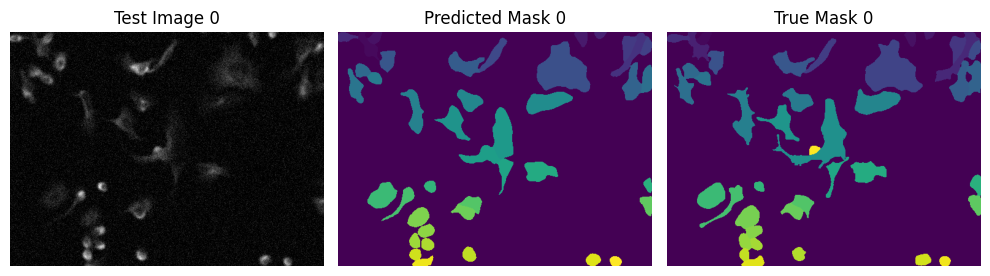

In [121]:
n = 0  # test image index to visualize
cyto_ch = 1  # channel index for cytoplasm (0=nucleus, 1=cytoplasm in this dataset)

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(test_data[n][cyto_ch], cmap="gray")
plt.title(f"Test Image {n}")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(masks[n])
plt.title(f"Predicted Mask {n}")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(test_labels[n])
plt.title(f"True Mask {n}")
plt.axis("off")
plt.tight_layout()
plt.show()

## Train New Model

Now we’re ready to train! In this step, we’ll tell Cellpose to:
- Use the training images and masks
- Save the trained model to your specified directory
- Run for a defined number of **epochs** (iterations over the full dataset)

You can also set other options like:
- Learning rate
- Batch size
- Whether to use GPU

> 💡 Training time will vary depending on your dataset size and hardware. On Google Colab with a GPU, small datasets may train in just a few minutes.

After training, the model weights will be saved and ready to use for predictions. We’ll evaluate performance on the test data in the next step.


In [ ]:
model_name = "new_model"
save_path = ROOT_FOLDER_PATH

# Training params
n_epochs = 20
learning_rate = 1e-5
weight_decay = 0.1
batch_size = 1

# (not passing test data into function to speed up training)

new_model_path, train_losses, test_losses = train.train_seg(
    model.net,
    train_data=train_data,
    train_labels=train_labels,
    test_data=test_data,
    test_labels=test_labels,
    batch_size=batch_size,
    n_epochs=n_epochs,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    nimg_per_epoch=max(2, len(train_data)),  # can change this
    model_name=model_name,
    save_path=save_path,
)

# NOTE: to speed up the training you can omit the test data and test labels from the
# `train_seg` function, but then you won't get test losses or a model saved at the epoch
# with the best test loss.

2026-06-05 17:09:31,439 [INFO] >>> converting bfloat16 network to float32 for training
2026-06-05 17:09:31,480 [INFO] computing flows for labels


100%|██████████| 8/8 [00:00<00:00, 11.34it/s]

2026-06-05 17:09:32,188 [INFO] computing flows for labels



100%|██████████| 3/3 [00:00<00:00, 20.34it/s]

2026-06-05 17:09:32,338 [INFO] >>> computing diameters



100%|██████████| 3/3 [00:00<00:00, 1878.61it/s]

2026-06-05 17:09:32,346 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-06-05 17:09:32,394 [INFO] >>> n_epochs=20, n_train=8, n_test=3
2026-06-05 17:09:32,394 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.10000
2026-06-05 17:09:32,395 [INFO] >>> saving model to /Users/fdrgsp/Desktop/05_segmentation_cellpose_training/models/new_model
2026-06-05 17:09:40,439 [INFO] 0, train_loss=0.5179, test_loss=0.2341, LR=0.000000, time 8.04s
2026-06-05 17:10:15,726 [INFO] 5, train_loss=0.4230, test_loss=0.1929, LR=0.000006, time 43.33s
2026-06-05 17:10:51,010 [INFO] 10, train_loss=0.4254, test_loss=0.1897, LR=0.000010, time 78.61s
2026-06-05 17:11:53,097 [INFO] saving network parameters to /Users/fdrgsp/Desktop/05_segmentation_cellpose_training/models/new_model
2026-06-05 17:11:56,212 [INFO] >>> converting network back to torch.bfloat16 after training


## Evaluate on test data

In [ ]:
model = models.CellposeModel(pretrained_model=new_model_path, gpu=use_gpu)

# run model on test images
masks = model.eval(test_data, batch_size=32)[0]

# check performance using ground truth labels
# average_precision returns AP at IoU thresholds [0.5, 0.75, 0.9] by default
values = metrics.average_precision(test_labels, masks)
average_precision, false_positives, false_negatives, _ = values

print(f"average precision at iou threshold 0.5  = {average_precision[:, 0].mean():.3f}")
print(f"average precision at iou threshold 0.75 = {average_precision[:, 1].mean():.3f}")
print(f"average precision at iou threshold 0.9  = {average_precision[:, 2].mean():.3f}")

print(f"average false positives per image = {false_positives.mean():.3f}")
print(f"average false negatives per image = {false_negatives.mean():.3f}")

In [ ]:
import matplotlib.pyplot as plt

output_dir = train_dir / "error_viz"
output_dir.mkdir(exist_ok=True)

# Run cpsam on all training images
model = models.CellposeModel(pretrained_model="cpsam", gpu=use_gpu)
train_preds = model.eval(train_data)[0]

for i, (image, gt, pred) in enumerate(zip(train_data, train_labels, train_preds)):
    img2d = image[0] if image.ndim == 3 else image

    gt_binary = gt > 0
    pred_binary = pred > 0

    # RGB error map: green=TP, red=FN (missed), blue=FP (extra)
    error = np.zeros((*gt_binary.shape, 3), dtype=np.uint8)
    error[gt_binary & pred_binary] = [0, 200, 0]
    error[gt_binary & ~pred_binary] = [220, 0, 0]
    error[~gt_binary & pred_binary] = [0, 80, 220]

    vmin, vmax = np.percentile(img2d, [1, 99])

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax in axes:
        ax.imshow(img2d, cmap="gray", vmin=vmin, vmax=vmax)
        ax.axis("off")

    axes[0].set_title("Raw image")
    axes[1].imshow(gt, alpha=0.4, cmap="tab20")
    axes[1].set_title("Ground truth")
    axes[2].imshow(error, alpha=0.5)
    axes[2].set_title("Errors — green: correct · red: missed · blue: extra")

    plt.suptitle(f"Train image {i:03d}", fontsize=12)
    plt.tight_layout()
    plt.savefig(output_dir / f"train_{i:03d}_errors.png", dpi=150, bbox_inches="tight")
    plt.close()

print(f"Saved {len(train_data)} visualizations → {output_dir}")